<b><u>Exercises</u></b><br>
<b>E01:</b> I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.<br>
<b>Results:</b> So after some digging and calculations, here’s what I noticed — when all weights and biases are initialized to zero, only b2 (the output layer bias) gets updated while everything else (W2, W1, b1, and C) stays dead. The reason is that the loss depends directly on the logits, and logits depend on h @ W2 + b2. Since all weights are zero, h becomes zero too, so the gradient flowing back into W2, W1, b1, and C is also zero. Only b2 gets a non-zero gradient and starts learning. Basically, b2 learns the unigram frequencies of the target characters (based purely on how often each character appears in Yb) without any context from the inputs. That’s why the loss still goes down, but the generated names are complete rubbish — the model is just guessing based on frequency and hasn’t learned any relationships between characters.

<b>E02:</b> BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.

In [23]:
# E01

In [24]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [25]:
words = open('names.txt', 'r').read().splitlines()

In [26]:
chars = sorted(list(set(''.join(words))))
stoi = {c:i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i:c for c, i in stoi.items()}

In [27]:
vocab_size = len(stoi)
block_size = 3 

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for c in w + '.':
            X.append(context)
            ix = stoi[c]
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(23)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182400, 3]) torch.Size([182400])
torch.Size([22887, 3]) torch.Size([22887])
torch.Size([22859, 3]) torch.Size([22859])


In [28]:
n_embd = 10 
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd))
W1 = torch.zeros((n_embd * block_size, n_hidden))
b1 = torch.zeros(n_hidden)
W2 = torch.zeros((n_hidden, vocab_size))
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [29]:
lossi = []

In [30]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # mini-batch 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    if i % 10000 == 0:
        print(f'{i}/{max_steps}: {loss.item()}')
    lossi.append(loss.log10().item())
    # break

0/200000: 3.295837163925171
10000/200000: 2.7069385051727295
20000/200000: 2.6942946910858154
30000/200000: 3.116281032562256
40000/200000: 2.6692092418670654
50000/200000: 3.082855701446533
60000/200000: 2.7203493118286133
70000/200000: 2.7799007892608643
80000/200000: 2.903346300125122
90000/200000: 2.7374558448791504
100000/200000: 2.8496768474578857
110000/200000: 2.9135167598724365
120000/200000: 3.0934174060821533
130000/200000: 2.6849167346954346
140000/200000: 2.9190659523010254
150000/200000: 2.9239776134490967
160000/200000: 2.8881285190582275
170000/200000: 2.7735798358917236
180000/200000: 2.9260799884796143
190000/200000: 2.8960516452789307


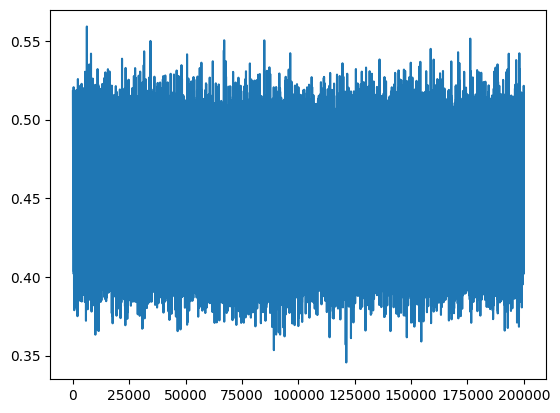

In [31]:
plt.plot(lossi)

In [32]:
# validate
@torch.no_grad()
def evaluate(split):
    X, Y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), 
        'test': (Xte, Yte)
    }[split]
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(f"{split} loss: {loss.item()}")

evaluate('train')
evaluate('val')

train loss: 2.8228769302368164
val loss: 2.8257765769958496


In [33]:
# sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    generated_word = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1 + b1
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        generated_word.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in generated_word))

narmahxaae.
hlrihkimrs.
reaty.
hnaassnejr.
hnenfamesahc.
iaeei.
.
elmaia.
ceaiiv.
e.
lein.
h.
.
m.
.
oin.
eeijn.
s.
lilea.
.


In [34]:
C

tensor([[-1.8067, -0.2458, -0.7222, -0.9417, -0.1870, -0.1258,  1.1827,  0.4672,
         -0.1328,  0.4220],
        [-0.4210,  0.3382, -2.3437, -0.7752, -1.5451, -0.7839, -0.1447, -0.5308,
          0.1580,  0.6105],
        [-0.0882, -0.4115,  0.3023,  0.0781,  1.6125, -0.8999,  0.7960,  0.5976,
          0.0746,  0.0481],
        [-0.6015, -0.5301, -1.3814, -0.7252,  0.8045, -1.2512,  1.7426, -0.0047,
         -0.5001,  0.6411],
        [-2.0935,  0.8630, -0.1760, -0.0445,  0.3407, -1.0290, -1.3102,  0.7930,
          0.1285, -2.3887],
        [-0.1042, -0.4363, -0.1881, -1.7856, -1.7463, -0.1253, -0.2953,  0.2353,
         -0.2591, -1.0237],
        [-1.8720,  0.0956, -0.6136,  0.2347,  0.2897,  1.6843, -1.3110,  0.5329,
         -0.2981,  0.1664],
        [-0.2539,  0.6565,  0.4517, -0.9741, -0.6354, -0.5419,  0.2882, -0.7438,
         -2.5066,  0.3258],
        [ 0.0398, -1.2409,  0.5319, -1.7796, -0.8774, -2.1343, -0.4494, -0.1982,
         -0.6146,  1.3583],
        [ 1.0405,  

In [35]:
W1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)

In [36]:
W2

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)

In [37]:
b1

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

In [38]:
b2

tensor([ 1.9157,  1.9907, -0.5834, -0.2694,  0.1558,  1.4731, -1.6241, -0.8921,
         0.5087,  1.3314, -0.4691,  0.0603,  1.1138,  0.3709,  1.3730,  0.5511,
        -1.5261, -2.7828,  0.9928,  0.5600,  0.1609, -0.3971, -0.5728, -1.6037,
        -1.9166,  0.7412, -0.6617], requires_grad=True)

In [39]:
C.grad

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],


In [40]:
W1.grad

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [41]:
W2.grad

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [42]:
b1.grad

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])

In [43]:
b2.grad

tensor([ 0.0137,  0.0871,  0.0114,  0.0156,  0.0239, -0.1298,  0.0040, -0.0541,
         0.0027, -0.0165, -0.0185,  0.0217, -0.0003,  0.0296, -0.0132,  0.0354,
         0.0044,  0.0013, -0.0387,  0.0045, -0.0073,  0.0137,  0.0115,  0.0041,
         0.0030, -0.0197,  0.0105])

In [45]:
# so after some calculations and analyzing, I have found that
# only b2 ie the output layer's bias is getting updated (ie only this part of the neural net is learning), rest of the neural net is dead
# ie because Loss is dependent on the logits
# logits are dependent on 2 terms h @ W2 and b2
# while doing backprop, we could see that b2 is getting updated whereas gradients of W2, b1, W1 and C are not being updated
# so only b2 is affecting the loss directly and it gets updated, it learns based on the frequency of the right charcaters
# and tries to maxmize that basically it will learn the frequences of the training set (unigram frequencies) based on Yb
# Yb is the true next character for a context ie 3 previous charcaters in our case, but this input becomes 0, and the 
# b2 tries to guess the frequencies of the next character without the context and tries to maximize its chance of guessing correctly
# hence the loss lowers, but it can't generate names when we have previous characters are context as it has not learned the relationships
# between characters and how they go together generally based on the training set

In [46]:
# E02